# LeetCode #528: Random Pick with Weight

https://leetcode.com/problems/random-pick-with-weight/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (expanded array)** | $O(W)$ init, $O(1)$ pick | $O(W)$ |
| **Optimal: Prefix Sum + Binary Search ★** | $O(n)$ init, $O(\log n)$ pick | $O(n)$ |

---

## Understanding the Methods

### Brute Force (expanded array)
Expand the weight array into a full list where index $i$ appears $w[i]$ times. Pick a random element. $O(W)$ space where $W = \sum w_i$ can be up to $10^9$.

### Optimal: Prefix Sum + Binary Search ★
Build a prefix sum array. For each pick, generate a random integer in $[1, \text{total}]$ and binary search for the first prefix sum $\ge$ that value. The index found is the answer. $O(n)$ init, $O(\log n)$ per pick, $O(n)$ space.

**Why this is better than Brute Force:** Prefix sums replace the expanded array entirely — space shrinks from $O(W)$ to $O(n)$, and picks remain fast at $O(\log n)$.

**Constraints:**
* $1 \le w.length \le 10^4$
* $1 \le w[i] \le 10^5$
* `pickIndex` is called at most $10^4$ times


## Solutions

### C#

In [ ]:
public class Solution {
    int[] prefix;
    Random rng = new Random();
    public Solution(int[] w) {
        // Build prefix sum array to encode cumulative weight
        prefix = new int[w.Length];
        prefix[0] = w[0];
        for (int i = 1; i < w.Length; i++) prefix[i] = prefix[i-1] + w[i];
    }
    public int PickIndex() {
        // Random target in [1, total]; find first prefix >= target
        int target = rng.Next(prefix[prefix.Length-1]) + 1;
        int lo = 0, hi = prefix.Length - 1;
        while (lo < hi) { int mid = lo+(hi-lo)/2; if (prefix[mid]<target) lo=mid+1; else hi=mid; }
        return lo;
    }
}

### Python

In [ ]:
import bisect
import random

class Solution:
    def __init__(self, w: list[int]):
        # Build prefix sum array to encode cumulative weight
        self.prefix: list[int] = []
        total = 0
        for weight in w:
            total += weight
            self.prefix.append(total)

    def pick_index(self) -> int:
        # Random target in [1, total]; find first prefix >= target
        target = random.randint(1, self.prefix[-1])
        return bisect.bisect_left(self.prefix, target)

### Go

In [ ]:
import (
    "math/rand"
    "sort"
)

type Solution struct {
    prefix []int
}

func Constructor(w []int) Solution {
    // Build prefix sum array to encode cumulative weight
    prefix := make([]int, len(w))
    prefix[0] = w[0]
    for i := 1; i < len(w); i++ {
        prefix[i] = prefix[i-1] + w[i]
    }
    return Solution{prefix: prefix}
}

func (s *Solution) PickIndex() int {
    // Random target in [1, total]; binary search for first prefix >= target
    target := rand.Intn(s.prefix[len(s.prefix)-1]) + 1
    return sort.SearchInts(s.prefix, target)
}

### Rust

In [ ]:
use rand::Rng;

struct Solution {
    prefix: Vec<i32>,
}

impl Solution {
    fn new(w: Vec<i32>) -> Self {
        // Build prefix sum array to encode cumulative weight
        let mut prefix = vec![0; w.len()];
        prefix[0] = w[0];
        for i in 1..w.len() {
            prefix[i] = prefix[i - 1] + w[i];
        }
        Solution { prefix }
    }

    fn pick_index(&self) -> i32 {
        // Random target in [1, total]; find first prefix >= target
        let target = rand::thread_rng().gen_range(1..=*self.prefix.last().unwrap());
        self.prefix.partition_point(|&x| x < target) as i32
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `w = [1, 3]`; call `pickIndex()` many times
Prefix = [1, 4]. Total = 4. Random in [1,4]: values 1 → index 0 (prob 1/4); values 2,3,4 → index 1 (prob 3/4). Index 1 is picked $\approx$ 3$\times$ more often.

**2. Slightly Complex**
**Input:** `w = [1, 2, 3, 4]`; pick once with target = 5
Prefix = [1, 3, 6, 10]. Binary search for first prefix $\ge$ 5: prefix[2]=6 $\ge$ 5 → index 2 returned. Weight 3 has a 30% probability.

**3. Edge Case: Time Factor**
**Input:** `w` has $10^4$ elements; call `pickIndex()` $10^4$ times
Each pick does $O(\log 10^4) \approx 14$ comparisons. All $10^4$ picks: $\approx 140{,}000$ operations — far faster than the $O(W)$ brute-force scan where $W$ could be $10^9$.

**4. Edge Case: Space Factor**
**Input:** `w = [10^5, 10^5, ..., 10^5]` ($10^4$ weights); total = $10^9$
Brute-force would need a $10^9$-element array. Prefix sum needs only $10^4$ integers — a $10^5\times$ space saving.

**5. Almost-Impossible but Plausible**
**Input:** `w = [1]` (single element); pick any number of times
Prefix = [1]. Random always yields target = 1; binary search returns index 0 immediately. The only valid index is always returned — correctness preserved at the boundary case.


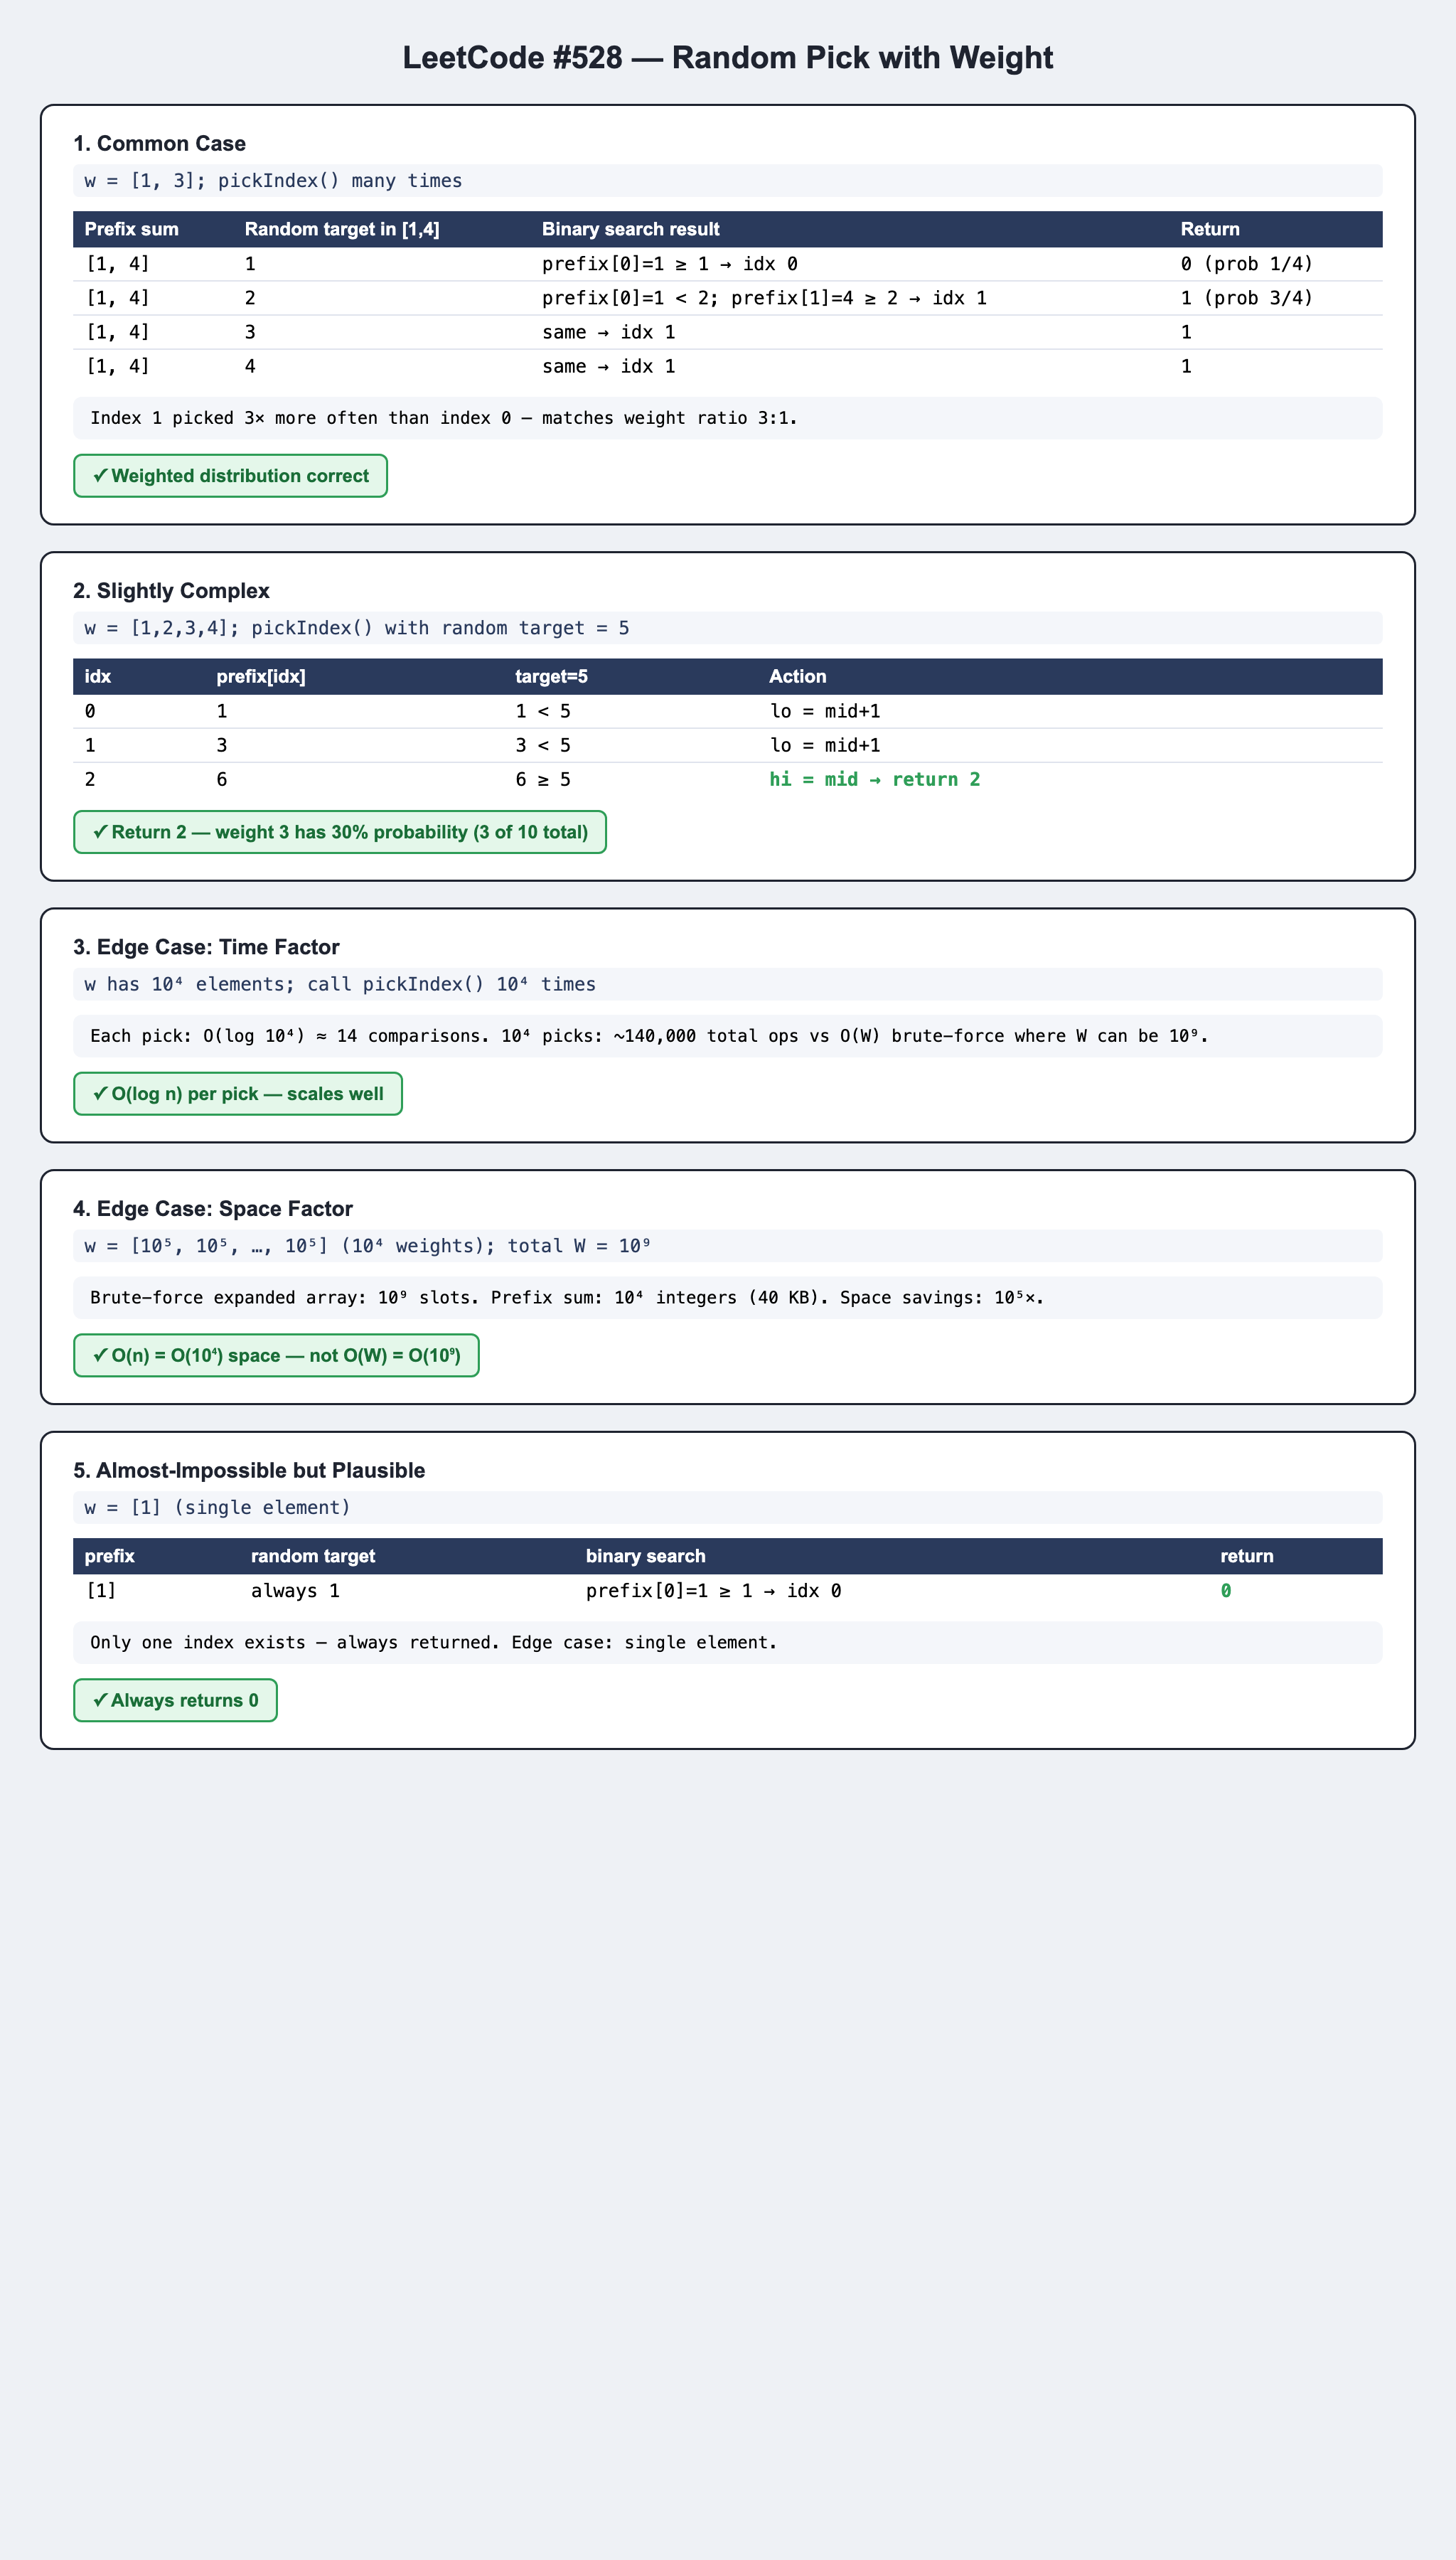